### Cell 1: Dataset Loading & Exploratory Data Analysis (EDA)
This cell initializes our workflow by importing the classic **Iris Flower dataset** natively from `sklearn.datasets`. We convert the raw matrix into a structured Pandas DataFrame to analyze its dimensions, summary statistics (`.describe()`), and structural balance. This initial pass confirms we have **150 total records across 4 distinct measurement features**, targeting 3 unique classification labels (`setosa`, `versicolor`, and `virginica`).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from joblib import dump, load

# 1. Load the Iris dataset
iris = load_iris()

# 2. Convert to Pandas DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

print("=== First 5 Rows ===")
print(df.head(), "\n")

print("=== Last 5 Rows ===")
print(df.tail(), "\n")

print(f"Dataset Shape: {df.shape} (Rows: {df.shape[0]}, Columns: {df.shape[1]})\n")

print("=== Concise Dataset Summary ===")
df.info()
print("\n=== Basic Statistical Summary ===")
print(df.describe(), "\n")

print("Feature Names:", iris.feature_names)
print("Target Names (Classes):", iris.target_names)
print("\nConfirmation: This is a classification task predicting 3 distinct categorical classes.")

=== First 5 Rows ===
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0   

=== Last 5 Rows ===
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149  

### Cell 2: Data Quality Verification & Stratified Splitting
Before manipulating data, we run quality assertions to ensure there are no missing (`null`) fields or duplicate anomalies skewing our data baseline. We then isolate our features ($X$) from our target classes ($y$) and perform an **80/20 train-test split**. Crucially, we apply `stratify=y` to guarantee that our training and testing subsets maintain perfectly balanced class proportions (50 samples per species), preserving real-world distribution integrity.

In [2]:
# 1. Verification checks
print(f"Total Missing Values:\n{df.isnull().sum()}\n")
print(f"Total Duplicate Rows Found: {df.duplicated().sum()}\n")

# 2. Separate input features (X) and target variable (y)
X = df[iris.feature_names]
y = df['target']

# 3. Train-Test Split (80/20, stratified by y to prevent class imbalance, reproducible seed)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape:  {X_test.shape}")
print(f"Training Target Class Distribution:\n{y_train.value_counts()}")

Total Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Total Duplicate Rows Found: 1

Training Features Shape: (120, 4)
Testing Features Shape:  (30, 4)
Training Target Class Distribution:
target
0    40
2    40
1    40
Name: count, dtype: int64


### Cell 3: Multi-Model Training & Classification Evaluation
Here, we train three distinct classification algorithms side-by-side: **Logistic Regression**, **Decision Tree**, and **Random Forest**. Because this is a classification task, we bypass regression metrics (like RMSE) and instead evaluate using **Accuracy, Precision, Recall, and F1-Score**. We display full Classification Reports and Confusion Matrices for each to evaluate exactly where models make correct versus incorrect predictions across the three species.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Initialize the models
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Dictionary to store performance metrics
results = {}

# Run training loop, scaling features inside the loop to observe test scores safely
for name, model in models.items():
    # Scale features manually here for comparison tracking
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics (using 'macro' average for multi-class setup)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    
    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1}
    
    print(f"================== {name} Full Classification Report ==================")
    print(classification_report(y_test, y_pred, target_names=iris.target_names))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred), "\n")

# Display final comparison table
df_compare = pd.DataFrame(results).T
print("================== Model Comparison Table ==================")
print(df_compare)

================== Logistic Regression Full Classification Report ==================
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]] 

================== Decision Tree Full Classification Report ==================
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Confusion Matrix:

### Cell 4: Model Accuracy Performance Visualization
To present our machine learning results intuitively, this cell utilizes `matplotlib` to generate a customized **Performance Comparison Bar Chart**. It dynamically reads our evaluation metrics, graphs the overall accuracy of each classifier along the Y-axis, and labels the exact scores directly on top of the bars for fast, clear visual analysis.

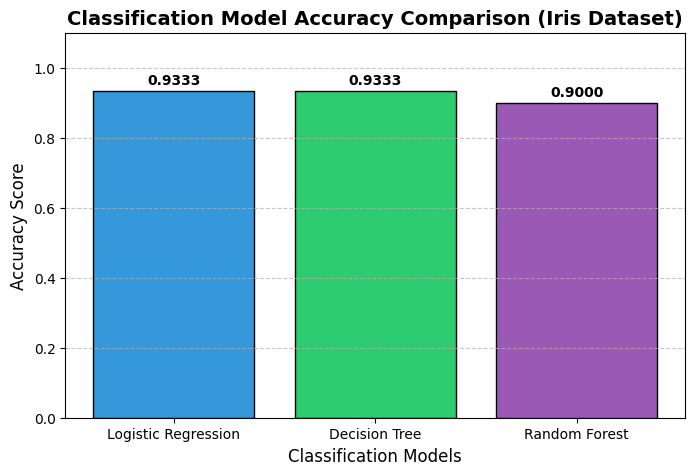

In [4]:
plt.figure(figsize=(8, 5))
bars = plt.bar(df_compare.index, df_compare['Accuracy'], color=['#3498db', '#2ecc71', '#9b59b6'], edgecolor='black')

# Add accuracy text labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

plt.title("Classification Model Accuracy Comparison (Iris Dataset)", fontsize=14, fontweight='bold')
plt.xlabel("Classification Models", fontsize=12)
plt.ylabel("Accuracy Score", fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Cell 5: Production Pipeline Engineering & Exporting
To guarantee architectural stability and completely eliminate the risk of **data leakage** during future usage, we bundle our data preparation (`StandardScaler`) and our highest-scoring classifier into a unified scikit-learn **Pipeline**. This encapsulates our entire processing logic into a single object, which we serialize and export to disk as an `iris_best_pipeline.joblib` file.

In [5]:
# Identify the best model dynamically from accuracy score
best_model_name = df_compare['Accuracy'].idxmax()
print(f"Best Performing Model Selected: {best_model_name}")

# Re-instantiate the chosen model based on the winner
if best_model_name == "Logistic Regression":
    best_clf = LogisticRegression(max_iter=200)
elif best_model_name == "Decision Tree":
    best_clf = DecisionTreeClassifier(random_state=42)
else:
    best_clf = RandomForestClassifier(random_state=42)

# Create the full scikit-learn Pipeline
iris_pipeline = Pipeline([
    ('scaler', StandardScaler()),       # Step 1: Standardize inputs
    ('classifier', best_clf)            # Step 2: Apply the best model
])

# Train the entire pipeline on the raw, unscaled training data
iris_pipeline.fit(X_train, y_train)

# Save the full pipeline artifact to disk
dump(iris_pipeline, 'iris_best_pipeline.joblib')
print("Success! Full scaling and classification pipeline saved securely as 'iris_best_pipeline.joblib'.")

Best Performing Model Selected: Logistic Regression
Success! Full scaling and classification pipeline saved securely as 'iris_best_pipeline.joblib'.


### Cell 6: Operational Pipeline Loading & Custom Entry Inference
This final cell simulates a real-world production deployment. We load our saved `.joblib` pipeline archive back into memory and feed it completely raw, unseen flower dimensions. The pipeline automatically applies the exact historical scaling variables before passing the inputs to the model. Finally, our code maps the resulting numeric index directly back to its human-readable species name string for the end user.

In [6]:
# 1. Load the saved pipeline artifact
loaded_pipeline = load('iris_best_pipeline.joblib')

print(">>> Enter Custom Flower Measurements for Production Inference <<<")
# Custom data inputs matching feature structure order: sepal length, sepal width, petal length, petal width
# Feel free to change these test numbers to test different plants!
custom_features = [[5.1, 3.5, 1.4, 0.2]] 

# Convert to matching DataFrame format to maintain feature names consistency
custom_df = pd.DataFrame(custom_features, columns=iris.feature_names)

# 2. Execute prediction using the pipeline (automatically applies the correct scaling matrix)
numeric_prediction = loaded_pipeline.predict(custom_df)

# 3. Translate numeric prediction integer index into actual plant species string name
predicted_species = iris.target_names[numeric_prediction[0]]

print("\n=== Production Prediction Results ===")
print(f"Input Measurements: {custom_features[0]}")
print(f"Predicted Class Index: {numeric_prediction[0]}")
print(f"Predicted Iris Species Type: **{predicted_species.upper()}**")


>>> Enter Custom Flower Measurements for Production Inference <<<

=== Production Prediction Results ===
Input Measurements: [5.1, 3.5, 1.4, 0.2]
Predicted Class Index: 0
Predicted Iris Species Type: **SETOSA**
